In [55]:
import  tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten
from tensorflow import keras

In [56]:
(X_train,y_train),(X_test,y_test)=keras.datasets.mnist.load_data()

In [57]:
y_test


array([7, 2, 1, ..., 4, 5, 6], shape=(10000,), dtype=uint8)

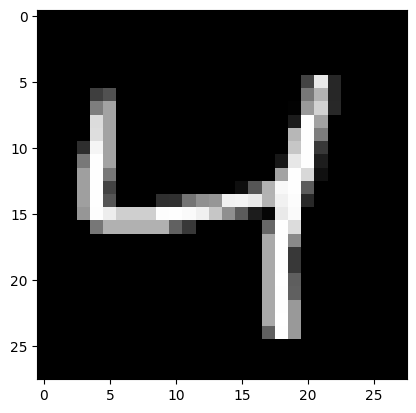

In [58]:
import matplotlib.pyplot as plt
plt.imshow(X_train[2],cmap="gray")

In [59]:
X_train=X_train/255
X_test=X_test/255

In [60]:
model =Sequential()
model.add(Flatten(input_shape=(28,28))) 
model.add(Dense(128,activation="relu"))
model.add(Dense(32,activation="relu"))
model.add(Dense(10,activation="softmax"))

c:\Users\Yaali Madad\Desktop\programs\Deeplearning\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [61]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
history=model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=25)

Epoch 1/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9253 - loss: 0.2577 - val_accuracy: 0.9617 - val_loss: 0.1248
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9674 - loss: 0.1057 - val_accuracy: 0.9720 - val_loss: 0.0944
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9776 - loss: 0.0732 - val_accuracy: 0.9718 - val_loss: 0.0889
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9822 - loss: 0.0557 - val_accuracy: 0.9742 - val_loss: 0.0802
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9859 - loss: 0.0443 - val_accuracy: 0.9725 - val_loss: 0.0934
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9887 - loss: 0.0350 - val_accuracy: 0.9754 - val_loss: 0.0901
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9902 - loss: 0.0304 - val_accuracy: 0.9775 - val_loss: 0.0787
Epoch 8/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9921 - loss: 0.0243 - 

In [63]:
y_prob=model.predict(X_test)
y_pred=y_prob.argmax(axis=1)
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


0.9786

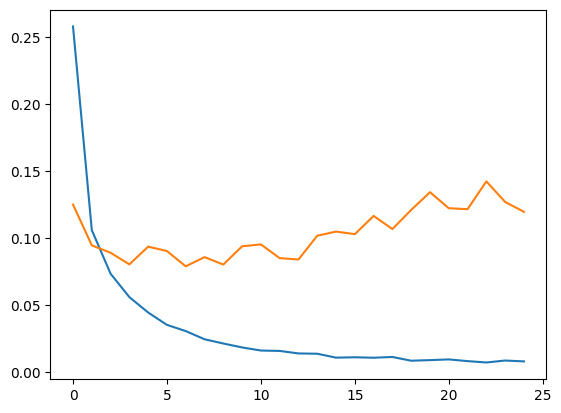

In [64]:
plt.plot(history.history["loss"],label="train loss")
plt.plot(history.history["val_loss"],label="test loss")